# E-Commerce Product Analytics: Conversion Funnel, A/B Testing & Unit Economics

## Project Objectives
This portfolio project focuses on extracting actionable product insights from the "Maven Fuzzy Factory" database using advanced SQL and Python. The core objectives are:
1. **Product Funnel Analysis:** Build a multi-step conversion funnel (from `/home` to `/billing`) to identify user drop-off points and optimize UX.
2. **A/B/n Testing:** Conduct statistical testing to compare experimental landing pages against the default homepage, identifying the optimal user entry point to maximize the final order conversion rate.
3. **Marketing Analytics & Traffic Optimization:** Analyze UTM parameters to evaluate campaign profitability (Revenue per Session), identify device-level purchasing behaviors for bid adjustments, and compare brand vs. non-brand traffic dynamics.
3. **Core Business Metrics:** Calculate and visualize key performance indicators, including Retention, AOV, ARPU (Average Revenue Per User), LTV, Refund Rate.

### [Tableau Dashboard](https://public.tableau.com/views/FuzzyFactoryMarketingDashboard/Dashboard?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

### Environment Setup & Database Connection
Instead of exporting data manually, we use `SQLAlchemy` to establish a direct connection to our MySQL database. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine

import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest

# Establish connection to MySQL
db_connection_str = 'mysql+pymysql://product_analyst:<YOUR_PASSWORD>@localhost:3306/maven_fuzzy_factory'
engine = create_engine(db_connection_str)

In [ ]:
files_to_load = [
    ('products', 'data/products.csv'),  
    ('website_sessions', 'data/website_sessions.csv'),
    ('website_pageviews', 'data/website_pageviews.csv'),
    ('orders', 'data/orders.csv'),
    ('order_items', 'data/order_items.csv'),
    ('order_item_refunds', 'data/order_item_refunds.csv')
]

for table_name, file_path in files_to_load:
    print(f"Reading {file_path}...")
    
    try:
        df = pd.read_csv(file_path)
        
        # Ingest data into the MySQL database
        # if_exists='append' ensures we populate the pre-built schema
        df.to_sql(
            name=table_name, 
            con=engine, 
            if_exists='append', 
            index=False,
            chunksize=10000 
        )
        print(f"Table '{table_name}' successfully populated! ({len(df)} rows)")
        
    except Exception as e:
        print(f"Error while loading table '{table_name}': {e}")

In [21]:
products_sql = '''
SELECT * FROM products
LIMIT 5
'''

products_df = pd.read_sql(products_sql, con = engine)
products_df

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [22]:
orders_sql = '''
SELECT * FROM orders
LIMIT 5
'''

orders_df = pd.read_sql(orders_sql, con = engine)
orders_df

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


In [23]:
order_items_sql = '''
SELECT * FROM order_items
LIMIT 5
'''

order_items_df = pd.read_sql(order_items_sql, con = engine)
order_items_df

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49


In [24]:
order_item_refunds_sql = '''
SELECT * FROM order_item_refunds
LIMIT 5
'''

order_item_refunds_df = pd.read_sql(order_item_refunds_sql, con = engine)
order_item_refunds_df

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99


In [25]:
website_sessions_sql = '''
SELECT * FROM website_sessions
LIMIT 5
'''

website_sessions_df = pd.read_sql(website_sessions_sql, con = engine)
website_sessions_df

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


In [26]:
website_pageviews_sql = '''
SELECT * FROM website_pageviews
LIMIT 5
'''

website_pageviews_df = pd.read_sql(website_pageviews_sql, con = engine)
website_pageviews_df

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home


## 1. Funnel Analysis
Before constructing the SQL query for our conversion funnel, it is critical to define the **"Happy Path"** — the ideal user journey from the first touchpoint to the final purchase.

We use the SQL `IN` operator to logically group similar URLs into consolidated funnel steps:

* **Step 1: Entry Pages (`/home` + `/lander-1` through `/lander-5`)** 
    The marketing team frequently runs A/B tests, directing ad traffic to dedicated landing pages (`/lander-...`) rather than the default `/home` page. If we only tracked `/home`, we would artificially lose hundreds of thousands of valid sessions from our top-of-funnel metrics. Grouping them ensures we capture the true entry volume regardless of the specific campaign.
    
* **Step 2: Product Detail Pages (PDP)**
    We group all four product URLs into a single `product_detail_page` step to accurately measure the total number of users who engaged with *any* item before proceeding to the cart.

* **Step 3: Checkout / Billing (`/billing` + `/billing-2`)**
    Similar to the entry pages, the billing step underwent an A/B test. Grouping these URLs ensures we account for all users who reached the final payment stage, regardless of the page version they were served.

In [27]:
# SQL query to check for missing (NULL) values in key columns
pageviews_null_check_sql = """
    SELECT 
        COUNT(*) AS total_rows,
        COUNT(*) - COUNT(website_pageview_id) AS null_pageview_id,
        COUNT(*) - COUNT(created_at) AS null_created_at,
        COUNT(*) - COUNT(website_session_id) AS null_session_id,
        COUNT(*) - COUNT(pageview_url) AS null_pageview_url
    FROM website_pageviews;
"""

pageviews_null_check_df = pd.read_sql(pageviews_null_check_sql, con=engine)
pageviews_null_check_df

,total_rows,null_pageview_id,null_created_at,null_session_id,null_pageview_url
0,1188124,0,0,0,0


In [28]:
top_pages_sql = '''
    SELECT 
        pageview_url, COUNT(pageview_url) AS total_pageviews
    FROM website_pageviews
    GROUP BY pageview_url
    ORDER BY COUNT(pageview_url) DESC
'''

top_pages_df = pd.read_sql(top_pages_sql, con=engine)
top_pages_df

,pageview_url,total_pageviews
0,/products,261231
1,/the-original-mr-fuzzy,162525
2,/home,137576
3,/lander-2,131170
4,/cart,94953
5,/lander-3,79000
6,/lander-5,68166
7,/shipping,64484
8,/billing-2,48441
9,/lander-1,47574


In [29]:
products_df

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


**Funnel Structure ("Happy Path"):**
1. **Entry Page (Top of Funnel):** `IN ('/home', '/lander-1', '/lander-2', '/lander-3', '/lander-4', '/lander-5')`
2. **Catalog Page:** `'/products'`
3. **Product Detail Page (PDP):** `IN ('/the-original-mr-fuzzy', '/the-forever-love-bear', '/the-birthday-sugar-panda', '/the-hudson-river-mini-bear')`
4. **Cart Page:** `'/cart'`
5. **Shipping Page:** `'/shipping'`
6. **Billing / Checkout Page:** `IN ('/billing', '/billing-2')`
7. **Order Completed (Conversion):** `'/thank-you-for-your-order'`

In [30]:
funnel_flags_sql = '''
    SELECT 
        website_session_id,
        MAX(CASE WHEN pageview_url IN (
            '/home', 
            '/lander-1', 
            '/lander-2', 
            '/lander-3', 
            '/lander-4', 
            '/lander-5'
        ) THEN 1 ELSE 0 END) as entry_page,
        MAX(CASE WHEN pageview_url = '/products' THEN 1 ELSE 0 END) as products_page,
        MAX(CASE WHEN pageview_url IN (
            '/the-original-mr-fuzzy', 
            '/the-forever-love-bear', 
            '/the-birthday-sugar-panda', 
            '/the-hudson-river-mini-bear' 
        ) THEN 1 ELSE 0 END) as product_detail_page,
        MAX(CASE WHEN pageview_url = '/cart' THEN 1 ELSE 0 END) as cart_page,
        MAX(CASE WHEN pageview_url = '/shipping' THEN 1 ELSE 0 END) as shipping_page,
        MAX(CASE WHEN pageview_url IN (
            '/billing',
            '/billing-2'
        ) THEN 1 ELSE 0 END) as billing_page,
        MAX(CASE WHEN pageview_url = '/thank-you-for-your-order' THEN 1 ELSE 0 END) as order_completed_page
    FROM website_pageviews
    GROUP BY website_session_id
'''

funnel_flags_df = pd.read_sql(funnel_flags_sql, con=engine)
funnel_flags_df

,website_session_id,entry_page,products_page,product_detail_page,cart_page,shipping_page,billing_page,order_completed_page
0,1,1,0,0,0,0,0,0
1,2,1,0,0,0,0,0,0
2,3,1,0,0,0,0,0,0
3,4,1,0,0,0,0,0,0
4,5,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
472866,472867,1,1,0,0,0,0,0
472867,472868,1,1,1,0,0,0,0
472868,472869,1,0,0,0,0,0,0
472869,472870,1,1,1,0,0,0,0


In [35]:
funnel_summary_sql = '''
    WITH cte AS (
        SELECT 
            website_session_id,
            MAX(CASE WHEN pageview_url IN (
                '/home', 
                '/lander-1', 
                '/lander-2', 
                '/lander-3', 
                '/lander-4', 
                '/lander-5'
            ) THEN 1 ELSE 0 END) as entry_page,
            MAX(CASE WHEN pageview_url = '/products' THEN 1 ELSE 0 END) as products_page,
            MAX(CASE WHEN pageview_url IN (
                '/the-original-mr-fuzzy', 
                '/the-forever-love-bear', 
                '/the-birthday-sugar-panda', 
                '/the-hudson-river-mini-bear' 
            ) THEN 1 ELSE 0 END) as product_detail_page,
            MAX(CASE WHEN pageview_url = '/cart' THEN 1 ELSE 0 END) as cart_page,
            MAX(CASE WHEN pageview_url = '/shipping' THEN 1 ELSE 0 END) as shipping_page,
            MAX(CASE WHEN pageview_url IN (
                '/billing',
                '/billing-2'
            ) THEN 1 ELSE 0 END) as billing_page,
            MAX(CASE WHEN pageview_url = '/thank-you-for-your-order' THEN 1 ELSE 0 END) as order_completed_page
        FROM website_pageviews
        GROUP BY website_session_id
    )

    SELECT 
        SUM(entry_page) AS total_entries,
        SUM(products_page) AS total_catalog,
        SUM(product_detail_page) AS total_pdp,
        SUM(cart_page) AS total_cart,
        SUM(shipping_page) AS total_shipping,
        SUM(billing_page) AS total_billing,
        SUM(order_completed_page) AS total_completed
    FROM cte
'''

funnel_summary_df = pd.read_sql(funnel_summary_sql, con=engine)
funnel_summary_df

,total_entries,total_catalog,total_pdp,total_cart,total_shipping,total_billing,total_completed
0,472871.0,261231.0,210214.0,94953.0,64484.0,52058.0,32313.0


In [36]:
# Transform data to Long Format
funnel_melted = funnel_summary_df.melt(
    var_name='funnel_step', 
    value_name='users_count'
)

funnel_melted

,funnel_step,users_count
0,total_entries,472871.0
1,total_catalog,261231.0
2,total_pdp,210214.0
3,total_cart,94953.0
4,total_shipping,64484.0
5,total_billing,52058.0
6,total_completed,32313.0


In [37]:
conversion_metrics_sql = '''
    with cte as (
        SELECT 
            *, 
            FIRST_VALUE(users_count) OVER () as top_of_funnel_users,
            LAG(users_count) OVER () as previous_step_users 
        FROM funnel_steps_long
    )

    SELECT 
        funnel_step,
        users_count, 
        ROUND(users_count / top_of_funnel_users * 100, 2) as overall_conversion_pct,
        ROUND((users_count / previous_step_users) * 100, 2) AS step_conversion_pct
    FROM cte
'''

conversion_metrics_df = pd.read_sql(conversion_metrics_sql, con=engine)
conversion_metrics_df

,funnel_step,users_count,overall_conversion_pct,step_conversion_pct
0,total_entries,472871.0,100.00,NaN
1,total_catalog,261231.0,55.24,55.24
2,total_pdp,210214.0,44.45,80.47
3,total_cart,94953.0,20.08,45.17
4,total_shipping,64484.0,13.64,67.91
5,total_billing,52058.0,11.01,80.73
6,total_completed,32313.0,6.83,62.07


In [38]:
step_names = {
    'total_entries': '1. Entry Pages',
    'total_catalog': '2. Catalog',
    'total_pdp': '3. Product Details (PDP)',
    'total_cart': '4. Cart',
    'total_shipping': '5. Shipping',
    'total_billing': '6. Billing',
    'total_completed': '7. Order Completed'
}

conversion_metrics_df['funnel_step'] = conversion_metrics_df['funnel_step'].replace(step_names)

conversion_metrics_df['custom_label'] = conversion_metrics_df['overall_conversion_pct'].astype(str) + '%'

fig = px.funnel(
    conversion_metrics_df, 
    x='users_count', 
    y='funnel_step',
    text='custom_label', 
    title='Product Conversion Funnel',
    labels={
        'users_count': 'Total Users', 
        'funnel_step': 'Step in Funnel'
    },
    color_discrete_sequence=['#1f77b4']
)

fig.update_traces(
    textposition='inside',
    textfont=dict(size=16, color='white') 
)

fig.update_layout(
    height=900,            
    width=1400,            
    title_font_size=22,
    title_x=0.5,           
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis_title=None       
)

fig.show()

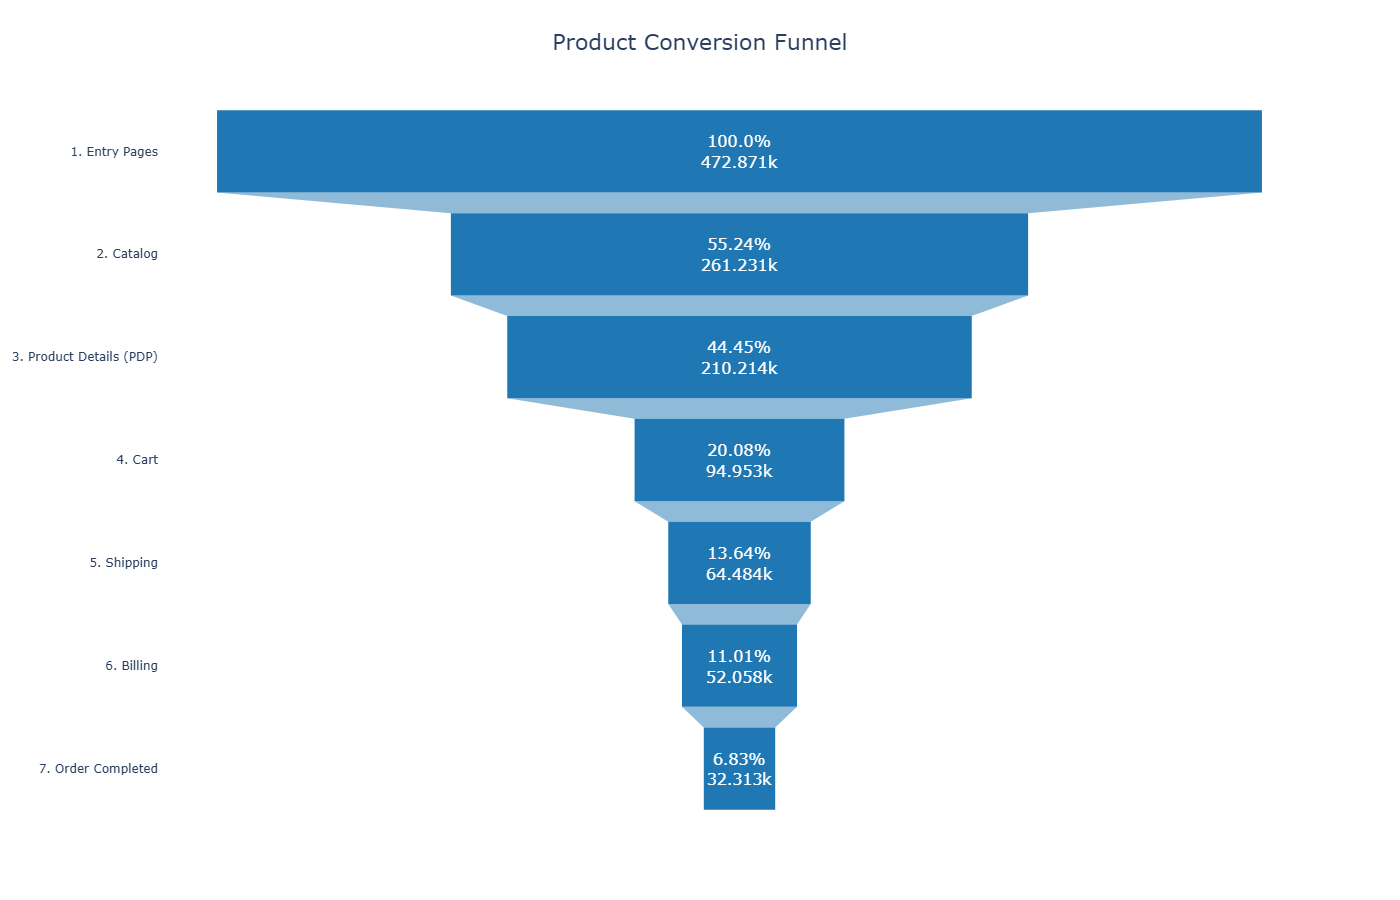

### Executive Insights & Funnel Optimization Strategy

Based on the interactive funnel metrics (Overall Conversion Rate: **6.83%**), we have identified three critical bottlenecks where the business is losing potential revenue:

**1. Top-of-Funnel Friction (Entry ➔ Catalog)**
* **Data:** Only **55.24%** of users proceed from their entry page to the catalog. Nearly 45% of our acquired traffic bounces immediately.
* **Hypothesis:** This high bounce rate suggests a potential mismatch between ad messaging and landing page content, slow page load times, or weak Call-to-Action (CTA) placement on the `/home` and `/lander` pages.
* **Recommendation:** Conduct A/B testing on landing page headlines and images to better align with marketing campaigns.

**2. Billing Conversion Gap (Billing ➔ Order Completed)**
* **Data:** **11.01%** of users reach the billing stage, but only **6.83%** successfully complete the order. This represents a massive ~38% relative drop-off at the very last step where users already have their credit cards out.
* **Hypothesis:** This is a critical revenue leak likely caused by technical payment gateway errors, a lack of trusted payment options (e.g., Apple Pay, PayPal), or unexpected fees appearing at the final step.
* **Recommendation:** Immediate technical audit of the `/billing` page. 

---

## 2. A/B/n Testing: Landing Page Optimization

### Objective & Strategic Pivot
While it is tempting to evaluate landing pages based on micro-conversions (e.g., Click-Through Rate to the `/products` catalog), doing so assumes a strict, linear user journey. Users might bypass the catalog entirely if the landing page features direct "Add to Cart" functionality. 

To account for all possible user flows and focus on the ultimate business impact, our primary target metric for this test is the **Macro-Conversion Rate**. We aim to determine if any custom landing page (`/lander-1` through `/lander-5`) yields a statistically significant increase in final purchases compared to the baseline `/home` page.

### Experiment Setup
* **Target Metric:** Order Conversion Rate $\left(\frac{\text{Total Orders}}{\text{Total Sessions}}\right)$
* **Control Group:** `/home`
* **Test Groups:** `/lander-1` to `/lander-5`

### Statistical Methodology
Since Conversion Rate is a proportion based on binary outcomes (Order vs. No Order), we apply a rigorous two-step statistical approach:
1. **Chi-Square Test:** First, we check for *any* statistically significant variance in conversion rates across all 6 pages combined.
2. **Pairwise Z-Tests for Proportions:** If the global test is significant, we run individual Z-tests to compare each `/lander` against `/home`.
3. **Bonferroni Correction:** To control the False Positive Rate across multiple comparisons, we adjust our significance threshold. For 5 targeted comparisons (each `/lander` vs. `/home`), our adjusted alpha becomes $\alpha = \frac{0.05}{5} = 0.01$. A variant is declared a winner only if its p-value is strictly less than 0.01.

In [39]:
ab_test_query = '''
    WITH session_flags AS (
        SELECT 
            website_session_id,
            MIN(website_pageview_id) as entry_pageview_id,
            MAX(CASE WHEN pageview_url = '/thank-you-for-your-order' THEN 1 ELSE 0 END) as order_completed
        FROM website_pageviews
        GROUP BY website_session_id 
    ),
    landing_pages AS (
        SELECT 
            f.website_session_id,
            p.pageview_url as landing_page,
            f.order_completed
        FROM session_flags f
        JOIN website_pageviews p 
            ON f.entry_pageview_id = p.website_pageview_id
        WHERE p.pageview_url IN ('/home', '/lander-1', '/lander-2', '/lander-3', '/lander-4', '/lander-5')
    )

    SELECT 
        landing_page,
        COUNT(website_session_id) as total_sessions,
        SUM(order_completed) as total_orders,
        ROUND(SUM(order_completed) / COUNT(website_session_id) * 100, 2) as conversion_rate_pct
    FROM landing_pages
    GROUP BY landing_page
    ORDER BY landing_page
'''

ab_test_df = pd.read_sql(ab_test_query, con=engine)
ab_test_df

,landing_page,total_sessions,total_orders,conversion_rate_pct
0,/home,137576,9711.0,7.06
1,/lander-1,47574,2157.0,4.53
2,/lander-2,131170,10128.0,7.72
3,/lander-3,79000,2679.0,3.39
4,/lander-4,9385,708.0,7.54
5,/lander-5,68166,6930.0,10.17


In [40]:
import scipy.stats as stats

ab_test_df['not_converted'] = ab_test_df['total_sessions'] - ab_test_df['total_orders']

# Build the contingency table [Successes, Failures]
contingency_table = ab_test_df[['total_orders', 'not_converted']].values

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.5e}\n") 

alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (H0).")
    print("The difference in conversion rates across landing pages is STATISTICALLY SIGNIFICANT.")
    print("We can proceed with pairwise Z-tests to identify the best performing variant.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis (H0).")
    print("The difference in conversion rates is due to random noise. No landing page had a significant effect.")

Chi-Square Statistic: 3235.69
P-value: 0.00000e+00

Conclusion: Reject the Null Hypothesis (H0).
The difference in conversion rates across landing pages is STATISTICALLY SIGNIFICANT.
We can proceed with pairwise Z-tests to identify the best performing variant.


In [41]:
control_data = ab_test_df[ab_test_df['landing_page'] == '/home'].iloc[0]
control_orders = control_data['total_orders']
control_sessions = control_data['total_sessions']
control_conv = control_data['conversion_rate_pct']

print(f"/home (Conversion Rate: {control_conv}%)\n")

alpha_corrected = 0.05 / 5

for index, row in ab_test_df.iterrows():
    variant = row['landing_page']
    
    if variant == '/home':
        continue
        
    variant_orders = row['total_orders']
    variant_sessions = row['total_sessions']
    variant_conv = row['conversion_rate_pct']
    
    successes = [variant_orders, control_orders]
    trials = [variant_sessions, control_sessions]
    
    z_stat, p_val = proportions_ztest(count=successes, nobs=trials)
    
    if p_val < alpha_corrected:
        if variant_conv > control_conv:
            status = "Significantly Better"
        else:
            status = "Significantly Worse"
    else:
        status = "No Significant Difference"
        
    print(f"Variant: {variant} (Conversion Rate: {variant_conv}%)")
    print(f"P-value: {p_val:.5e} | Threshold: {alpha_corrected}")
    print(f"Status:  {status}")
    print("-" * 60)

/home (Conversion Rate: 7.06%)

Variant: /lander-1 (Conversion Rate: 4.53%)
P-value: 1.13771e-83 | Threshold: 0.01
Status:  Significantly Worse
------------------------------------------------------------
Variant: /lander-2 (Conversion Rate: 7.72%)
P-value: 5.14031e-11 | Threshold: 0.01
Status:  Significantly Better
------------------------------------------------------------
Variant: /lander-3 (Conversion Rate: 3.39%)
P-value: 3.95621e-274 | Threshold: 0.01
Status:  Significantly Worse
------------------------------------------------------------
Variant: /lander-4 (Conversion Rate: 7.54%)
P-value: 7.63281e-02 | Threshold: 0.01
Status:  No Significant Difference
------------------------------------------------------------
Variant: /lander-5 (Conversion Rate: 10.17%)
P-value: 8.47367e-131 | Threshold: 0.01
Status:  Significantly Better
------------------------------------------------------------


### Business Conclusions & Recommendations

Based on thу A/B/n testing and pairwise Z-tests with Bonferroni correction ($\alpha = 0.01$), we can draw the following data-driven conclusions:

*  `/lander-5` is the clear champion, yielding a **10.17%** conversion rate compared to the `/home` baseline of 7.06%. The p-value is practically zero, indicating extreme statistical significance.
*  `/lander-2` also significantly outperformed the baseline (7.72%), but falls short of the performance seen in `/lander-5`.
* **The "Illusion" of Success:** `/lander-4` presents a fascinating case. While its nominal conversion rate (7.54%) appears higher than the baseline, the p-value of 0.076 exceeds our strict 0.01 threshold. This result is not statistically significant and is likely due to random variance.
* **The Underperformers:** `/lander-1` (4.53%) and `/lander-3` (3.39%) significantly harmed the conversion rate and should be retired immediately.

**Final Recommendation:**
The marketing and engineering teams should immediately deprecate all experimental landing pages and the baseline `/home` page for paid traffic. **Roll out `/lander-5` to 100% of incoming ad traffic.** This single product change is projected to increase the overall baseline conversion rate by approximately 3 percentage points, driving massive incremental revenue.

---

## 3. Marketing Analytics & Traffic Optimization

### Strategic Objective
Having optimized the product entry point via A/B testing, we now shift our focus to the top of the funnel: **Traffic Acquisition**. We must evaluate the *quality* and *profitability* of our traffic to ensure optimal allocation of the marketing budget.

In this section, we will leverage SQL to extract and analyze UTM parameters, answering three critical business questions:

1. **Campaign Profitability (Revenue per Session):** Which traffic sources and campaigns yield the highest return on ad spend? By calculating the Revenue per Session (RPS), we will identify exactly which channels deserve a budget increase.
2. **Device-Level Bidding Strategy:** How do purchasing behaviors differ between mobile and desktop users? We will analyze conversion rates and revenue by device type to recommend data-driven bid adjustments for Google Ads.
3. **Brand vs. Non-Brand Traffic Dynamics:** What is the behavioral difference between high-intent "warm" users (searching for our specific brand) and generic explorers? 

In [42]:
marketing_sql = '''
    WITH OrderRefunds AS (
        SELECT 
            order_id,
            SUM(refund_amount_usd) AS total_refund_amount
        FROM order_item_refunds
        GROUP BY order_id
    )

    SELECT 
        COALESCE(s.utm_source, 'organic_direct') AS utm_source,
        COALESCE(s.utm_campaign, 'organic_direct') AS utm_campaign,
        COALESCE(s.utm_content, 'organic_direct') AS utm_content,
        s.device_type,
        COUNT(DISTINCT o.order_id) as total_orders,
        COUNT(DISTINCT s.website_session_id) AS total_sessions,
        SUM(o.price_usd) AS total_gross_revenue,
        SUM(o.price_usd) - COALESCE(SUM(r.total_refund_amount), 0) AS total_net_revenue
        
    FROM website_sessions s 
    LEFT JOIN orders o ON s.website_session_id = o.website_session_id
    LEFT JOIN OrderRefunds r ON o.order_id = r.order_id 
    GROUP BY s.utm_source, s.utm_campaign, s.utm_content, s.device_type
    ORDER BY utm_source, utm_campaign, utm_content
'''

marketing_df = pd.read_sql(marketing_sql, con=engine)
display(marketing_df.head())

,utm_source,utm_campaign,utm_content,device_type,total_orders,total_sessions,total_gross_revenue,total_net_revenue
0,bsearch,brand,b_ad_2,desktop,677,6867,41645.31,39889.67
1,bsearch,brand,b_ad_2,mobile,24,1047,1463.71,1363.73
2,bsearch,nonbrand,b_ad_1,desktop,3584,47395,211434.40,202506.21
3,bsearch,nonbrand,b_ad_1,mobile,234,7514,14129.08,13353.24
4,gsearch,brand,g_ad_2,desktop,2100,19922,126801.76,121022.93


In [43]:
# 1. Device Performance
device_df = marketing_df.groupby('device_type')[['total_orders', 'total_sessions', 'total_net_revenue']].sum().reset_index()
device_df['revenue_per_session'] = round(device_df['total_net_revenue'] / device_df['total_sessions'], 2)
device_df['conversion_rate'] = round(device_df['total_orders']/device_df['total_sessions'] * 100, 2)
device_df.sort_values('revenue_per_session', ascending=False)

,device_type,total_orders,total_sessions,total_net_revenue,revenue_per_session,conversion_rate
0,desktop,27805,327027,1592758.66,4.87,8.50
1,mobile,4508,145844,260412.40,1.79,3.09


In [44]:
# 2. Brand vs Non-Brand 
search_df = marketing_df[marketing_df['utm_source'].isin(['gsearch', 'bsearch'])]
brand_df = search_df.groupby('utm_campaign')[['total_orders', 'total_sessions', 'total_net_revenue']].sum().reset_index()
brand_df['revenue_per_session'] = round(brand_df['total_net_revenue'] / brand_df['total_sessions'], 2)
brand_df['conversion_rate'] = round(brand_df['total_orders']/brand_df['total_sessions'] * 100, 2)
brand_df.sort_values('revenue_per_session', ascending=False)

,utm_campaign,total_orders,total_sessions,total_net_revenue,revenue_per_session,conversion_rate
0,brand,3212,41243,186233.44,4.52,7.79
1,nonbrand,22640,337615,1289969.84,3.82,6.71


In [45]:
# 3. Source Performance
source_df = marketing_df.groupby('utm_source')[['total_orders', 'total_sessions', 'total_net_revenue']].sum().reset_index()
source_df['revenue_per_session'] = round(source_df['total_net_revenue'] / source_df['total_sessions'], 2)
source_df['conversion_rate'] = round(source_df['total_orders']/source_df['total_sessions'] * 100, 2)
source_df.sort_values('revenue_per_session', ascending=False)

,utm_source,total_orders,total_sessions,total_net_revenue,revenue_per_session,conversion_rate
2,organic_direct,6118,83328,355740.23,4.27,7.34
0,bsearch,4519,62823,257112.85,4.09,7.19
1,gsearch,21333,316035,1219090.43,3.86,6.75
3,socialbook,343,10685,21227.55,1.99,3.21


### Strategic Marketing Insights & Recommendations

Based on the multi-dimensional analysis of our traffic and revenue per session (RPS), we have identified several critical opportunities for budget optimization:

1. **Implement Aggressive Device-Level Bidding:**
   * **Finding:** Desktop users generate a massive **$4.87 RPS** with **8.50% CVR**, compared to just **$1.79 RPS** with **3.09% CVR** for mobile users. 
   * **Recommendation:** The marketing team should immediately apply a positive bid adjustment for Desktop traffic to capture more of this highly profitable segment, while significantly reducing bids for Mobile traffic until the mobile UX is improved.

2. **Reallocate Search Engine Budget (The Bing Opportunity):**
   * **Finding:** While Google Search (`gsearch`) drives the highest volume (316035 Sessions), Bing Search (`bsearch`) is actually more efficient, generating **$4.09 RPS** and **7.19% CVR** versus Google's $3.86 RPS with 6.75% CVR.
   * **Recommendation:** Scale the advertising budget for `bsearch`. Since the traffic is highly qualified, increasing our impression share on Bing will likely yield a higher Return on Ad Spend (ROAS).

3. **Investigate Social Media Performance (Socialbook):**
   * **Finding:** `socialbook` campaigns yield a lower RPS of **$1.99** and lower CVR of **3.21%**, which is expected for top-of-funnel social traffic compared to high-intent search traffic.
   * **Analytical Nuance:** A lower RPS does not automatically imply unprofitability, as social media cost-per-click (CPC) is typically much lower than search engine bids.
   * **Next Step:** To calculate exact ROAS (Return on Ad Spend), we need to integrate marketing cost data. If the acquisition cost per session is significantly below $1.99, this channel remains a highly viable source for low-cost volume growth.

---

## 4. Core Business Metrics

### Strategic Objective
While traffic acquisition and conversion rates show how well we bring customers in, the true health of an e-commerce business is measured by what happens *after* the first sale. Are customers satisfied? Do they come back? Is the unit economics sustainable long-term?

In this final section, we will calculate the fundamental macro-metrics of our business:
* **Sales Volume & AOV Trends**
* **Cohort Analysis (User Retention):** 
* **Customer Lifetime Value (LTV) & ARPU** 
* **Refund Rate** 

### **Sales Volume & AOV Trends**

Overall Average Order Value 

In [46]:
query = '''
    SELECT 
        ROUND(AVG(price_usd), 2) as AOV 
    FROM orders
'''

pd.read_sql(query, con=engine)

,AOV
0,59.99


Monthly AOV Trends

In [47]:
monthly_sales_sql = '''
    SELECT 
        DATE_FORMAT(created_at, '%%Y-%%m') AS order_month, 
        COUNT(order_id) as total_orders,
        SUM(price_usd) as total_sales,
        ROUND(AVG(price_usd), 2) as AOV
    FROM orders
    GROUP BY order_month
'''

monthly_sales_df = pd.read_sql(monthly_sales_sql, con=engine)
monthly_sales_df

,order_month,total_orders,total_sales,AOV
0,2012-03,60,2999.40,49.99
1,2012-04,99,4949.01,49.99
2,2012-05,108,5398.92,49.99
3,2012-06,140,6998.60,49.99
4,2012-07,169,8448.31,49.99
5,2012-08,228,11397.72,49.99
6,2012-09,287,14347.13,49.99
7,2012-10,371,18546.29,49.99
8,2012-11,618,30893.82,49.99
9,2012-12,506,25294.94,49.99


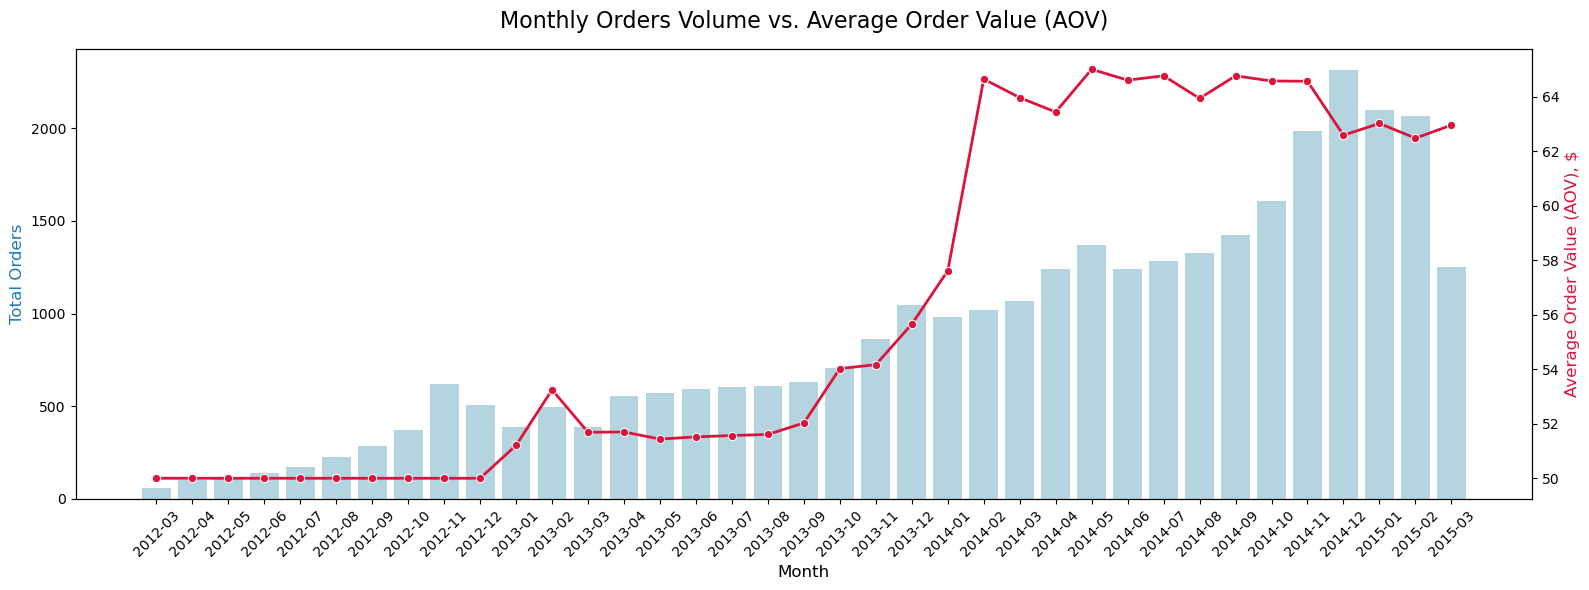

In [48]:
fig, ax1 = plt.subplots(figsize=(16, 6))

sns.barplot(
    data=monthly_sales_df, 
    x='order_month', 
    y='total_orders', 
    color='lightblue', 
    ax=ax1
)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Orders', color='tab:blue', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()

sns.lineplot(
    data=monthly_sales_df, 
    x='order_month', 
    y='AOV', 
    color='crimson', 
    marker='o',      
    linewidth=2, 
    ax=ax2
)
ax2.set_ylabel('Average Order Value (AOV), $', color='crimson', fontsize=12)

plt.title('Monthly Orders Volume vs. Average Order Value (AOV)', fontsize=16, pad=15)
plt.tight_layout();

### AOV Trend Insights

The dual-axis chart reveals the evolutionary phases of the business:

1. **Single-Product Era (2012):** A flat AOV of ~$49.99 indicates the company started with a single product and no cross-selling capabilities. Every customer bought exactly one item.
2. **Successful Product Expansion (2013-2014):** The significant jumps in AOV (reaching ~$65 by early 2014) strongly suggest successful new product launches and the implementation of cross-selling features. The business successfully increased its revenue per transaction.
3. **Volume and Value Synergy:** Crucially, the increase in average order value did not hurt conversion rates. The total volume of orders (blue bars) continued to grow. 

---

### **Cohort Analysis (User Retention)**

In [49]:
cohort_sql = '''
    SELECT 
        user_id,
        DATE_FORMAT(created_at, '%%Y-%%m') AS order_month,
        DATE_FORMAT(MIN(created_at) OVER (PARTITION BY user_id), '%%Y-%%m') as first_order_month
    FROM orders
'''

cohort_df = pd.read_sql(cohort_sql, con=engine)
cohort_df

,user_id,order_month,first_order_month
0,13,2012-04,2012-04
1,20,2012-03,2012-03
2,59,2012-04,2012-04
3,104,2012-03,2012-03
4,147,2012-03,2012-03
...,...,...,...
32308,394231,2015-03,2015-03
32309,394255,2015-03,2015-03
32310,394257,2015-03,2015-03
32311,394268,2015-03,2015-03


In [50]:
cohort_df.dtypes

user_id              int64
order_month            str
first_order_month      str
dtype: object

In [51]:
cohort_df['order_month'] = pd.to_datetime(cohort_df['order_month'])
cohort_df['first_order_month'] = pd.to_datetime(cohort_df['first_order_month'])

In [52]:
year_diff = cohort_df['order_month'].dt.year - cohort_df['first_order_month'].dt.year
month_diff = cohort_df['order_month'].dt.month - cohort_df['first_order_month'].dt.month
cohort_df['cohort_index'] = year_diff * 12 + month_diff

In [53]:
cohort_data = cohort_df.groupby(['first_order_month', 'cohort_index'])['user_id'].nunique().reset_index()

In [54]:
cohort_pivot = cohort_data.pivot(index='first_order_month', columns='cohort_index', values='user_id')

In [55]:
cohort_sizes = cohort_pivot.iloc[:, 0] 
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)
retention_matrix = retention_matrix.drop(columns=[0])
retention_matrix.index = retention_matrix.index.strftime('%Y-%m')

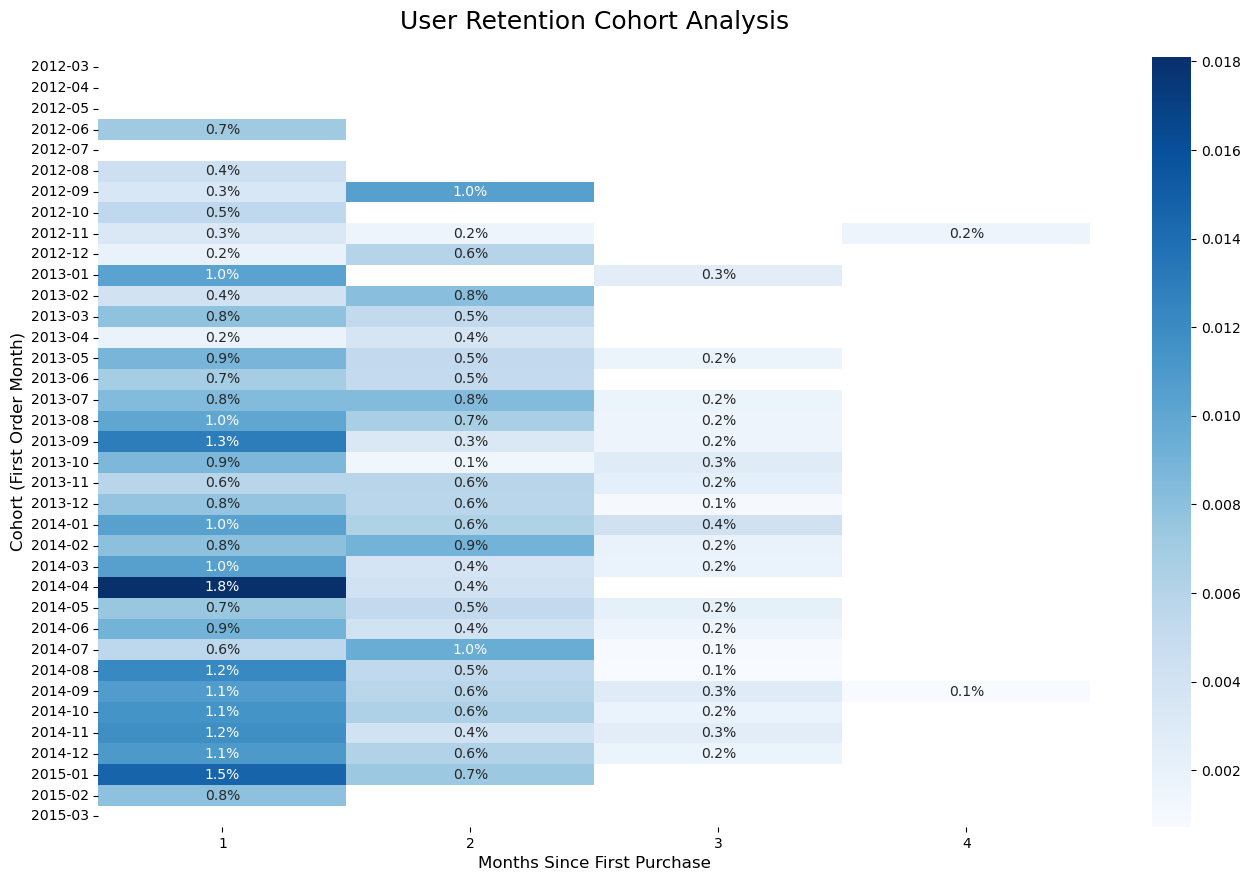

In [56]:
plt.figure(figsize=(16, 10))
plt.title('User Retention Cohort Analysis', fontsize=18, pad=20)

sns.heatmap(
    retention_matrix, 
    annot=True,          
    fmt='.1%',           
    cmap='Blues'        
)

plt.ylabel('Cohort (First Order Month)', fontsize=12)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.yticks(rotation=0);

### Retention & LTV Insights

The Cohort Analysis reveals a critical characteristic of our business model:

1. **Extremely Low Repeat Purchase Rate:** Our Month-1 retention sits at approximately **1%**, and rapidly decays to near-zero in subsequent months. 
2. **LTV ≈ AOV:** Because 98-99% of customers never make a second purchase, our Customer Lifetime Value (LTV) is essentially capped at the Average Order Value of their first transaction. The company has successfully increased that baseline LTV from $50 to $65 over two years.

----

### **ARPU**

In [57]:
arpu_sql = '''
    WITH order_revenue AS (
        SELECT 
            i.order_id,
            SUM(i.price_usd) as total_price_usd,
            SUM(COALESCE(r.refund_amount_usd, 0)) as total_refund_amount_usd,
            SUM(i.price_usd) - SUM(COALESCE(r.refund_amount_usd, 0)) as revenue 
        FROM order_items i
        LEFT JOIN order_item_refunds r ON i.order_item_id = r.order_item_id
        GROUP BY order_id
    ),

    user_revenue AS (
        SELECT 
            o.user_id,
            SUM(r.revenue) as revenue
        FROM order_revenue r
        JOIN orders o ON r.order_id = o.order_id
        GROUP BY o.user_id
    )

    SELECT
        ROUND(SUM(revenue)/COUNT(DISTINCT user_id), 2) as ARPU
    FROM user_revenue
'''

arpu_df = pd.read_sql(arpu_sql, con=engine)
arpu_df

,ARPU
0,58.47


### ARPU & LTV

Based on the calculation above, our historical **Average Revenue Per User (ARPU) is $58.47** (net of refunds). 

Given the insights from our Cohort Analysis (repeat purchase rate ~1%), we can confidently state that for this business model:
`Customer Lifetime Value (LTV) ≈ ARPU ≈ $58.47`

**Strategic Takeaway:** Since a customer is worth strictly ~\$58.47 to the business overall, our marketing team has a hard, unyielding ceiling. To maintain a profitable business, our fully-loaded **Customer Acquisition Cost (CAC) must remain significantly below $58.47**, ideally at a 3:1 ratio (CAC < $19.50).

---

### **Refund Rate**

Overall Refund Rate

In [58]:
query = '''
    SELECT
        ROUND(COUNT(r.order_item_refund_id)/COUNT(i.order_item_id) * 100, 2) as Refund_Rate
    FROM order_items i
    LEFT JOIN order_item_refunds r ON i.order_item_id = r.order_item_id
'''

pd.read_sql(query, con=engine)

,Refund_Rate
0,4.32


Monthly Refund Rate Trend

In [59]:
refund_rate_sql = '''
    SELECT
        DATE_FORMAT(i.created_at, '%%Y-%%m') as order_month,
        COUNT(i.order_item_id) as total_items_sold,
        COUNT(r.order_item_refund_id) as total_refunds,
        ROUND(COUNT(r.order_item_refund_id)/COUNT(i.order_item_id) * 100, 2) as Refund_Rate
    FROM order_items i
    LEFT JOIN order_item_refunds r ON i.order_item_id = r.order_item_id
    GROUP BY DATE_FORMAT(i.created_at, '%%Y-%%m') 
'''

refund_rate_df = pd.read_sql(refund_rate_sql, con=engine)
refund_rate_df

,order_month,total_items_sold,total_refunds,Refund_Rate
0,2012-03,60,1,1.67
1,2012-04,99,5,5.05
2,2012-05,108,4,3.70
3,2012-06,140,8,5.71
4,2012-07,169,14,8.28
5,2012-08,228,17,7.46
6,2012-09,287,26,9.06
7,2012-10,371,27,7.28
8,2012-11,618,46,7.44
9,2012-12,506,30,5.93


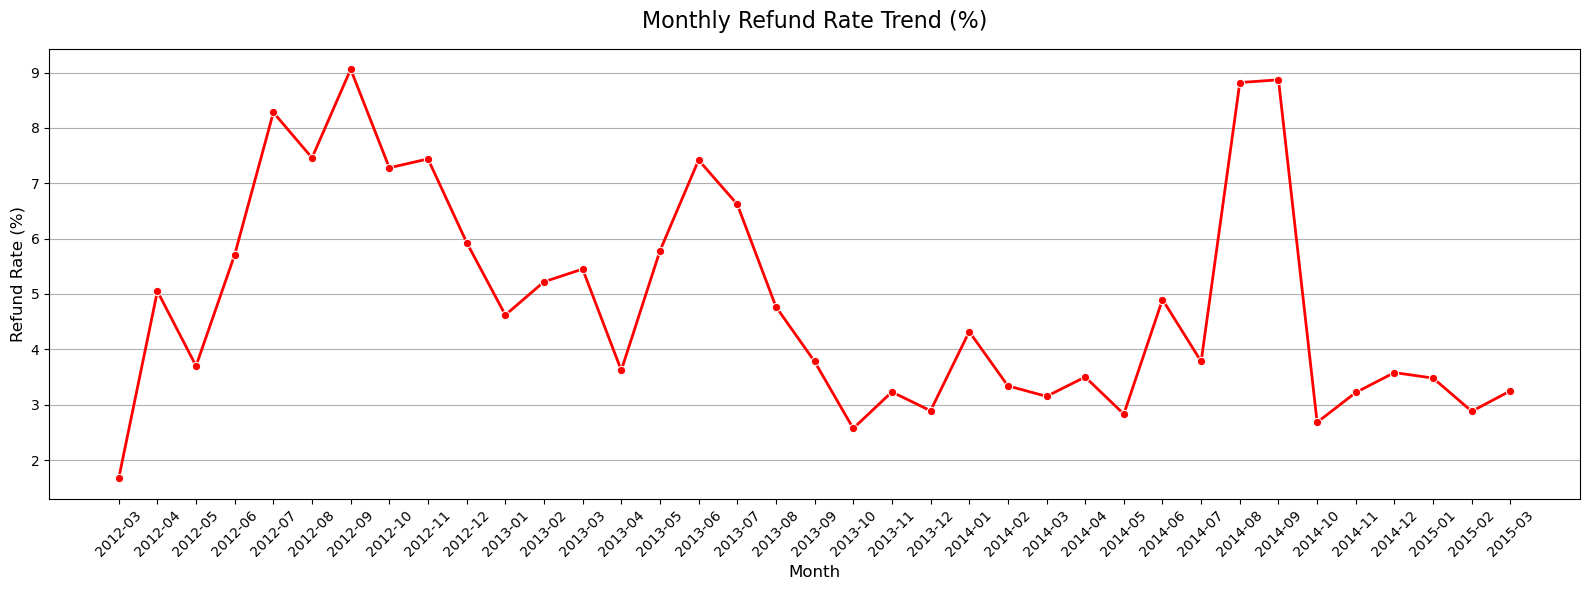

In [60]:
plt.figure(figsize=(16, 6))

sns.lineplot(refund_rate_df, 
            x = 'order_month',
            y = 'Refund_Rate',
            color='red', 
            marker='o',
            linewidth=2)

plt.title('Monthly Refund Rate Trend (%)', fontsize=16, pad=15)
plt.ylabel('Refund Rate (%)', fontsize=12)
plt.xlabel('Month', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout();

### Refund Rate Insights 

By correlating the Refund Rate trend with our previous AOV and Volume analysis, we can identify specific operational events:

1. **Initial Volatility (2012):** The business experienced high fluctuations in refund rates during its first year (peaking near 9%), typical for a startup establishing its supply chain.
2. **Quality Stability During Expansion (2013 - Mid 2014):** Even though the company successfully launched new products and increased AOV to ~$65 in February 2014, the refund rate remained exceptionally healthy (3% - 4.5%) for the next six months. This proves the initial product expansion was high-quality.
3. **Isolated Supply Chain Crisis (Aug-Sep 2014):** We observe a sudden, severe spike to nearly **9% in August and September 2014**. Since the catalog and AOV had been stable for months prior, this isolated spike strongly points to a specific **defective manufacturing batch**, a problematic **change in suppliers**, or a temporary **fulfillment center failure**.
4. **Swift Resolution:** Fortunately, management reacted quickly. The defective inventory or operational issue was resolved just in time for the critical Q4 holiday season, dropping the refund rate back to ~3% by October 2014.

---

# Final Executive Summary: Business Insights & Strategic Recommendations

Based on the comprehensive end-to-end analysis of Maven Fuzzy Factory's database (funnel analysis, traffic acquisition, A/B/n testing, cohort retention, Average Order Value (AOV), Unit Economics (ARPU), and Refund Rates) we have uncovered a clear picture of the company's operational health and strategic bottlenecks.

## Key Business Findings

### 1. Billing Page Problem
Our funnel analysis exposed a severe drop-off at the final checkout step. While 11.01% of all traffic reaches the `/billing` page, only 6.83% successfully complete the order.
* **Insight:** This represents a massive **~38% relative abandonment rate** exactly when users have their credit cards ready. This strongly implies severe friction in the payment process (e.g., payment gateway technical errors, "sticker shock" from hidden shipping costs, or lack of trusted alternative payment methods like Apple Pay/PayPal).

### 2. Traffic Acquisition & Device Performance
Our top-of-funnel analysis revealed distinct patterns across marketing channels and user devices:
* **Channel Dominance:** `gsearch` (Google Search) is the primary driver of our traffic and volume, while `bsearch` (Bing) and `socialbook` act as secondary channels. While Google Search (`gsearch`) drives the highest volume (316035 Sessions), Bing Search (`bsearch`) is actually more efficient, generating **$4.09 RPS** and **7.19% CVR** versus Google's $3.86 RPS with 6.75% CVR.
* **The Device Divide:** There is a significant performance gap between devices. `desktop` users consistently show higher conversion rates compared to `mobile` traffic, meaning our mobile web experience may be leaking potential revenue.

### 3. A/B/n Testing: Landing Page Optimization
While it is tempting to evaluate landing pages based on micro-conversions (e.g., Click-Through Rate to the `/products` catalog), doing so assumes a strict, linear user journey. Users might bypass the catalog entirely if the landing page features direct "Add to Cart" functionality. To account for all possible user flows, our primary target metric for this test is the **Macro-Conversion Rate**. 

* **Target Metric:** Order Conversion Rate $\left(\frac{\text{Total Orders}}{\text{Total Sessions}}\right)$
* **Control Group:** `/home`
* **Test Groups:** `/lander-1` to `/lander-5`
* **Hypotheses:**
    * **$H_0$ (Null Hypothesis):** None of the custom landing pages (`/lander-1` to `/lander-5`) produce a statistically significant difference in the Order Conversion Rate compared to the baseline `/home` page.
    * **$H_1$ (Alternative Hypothesis):** At least one of the custom landing pages produces a statistically significant difference in the Order Conversion Rate compared to the baseline.

**Statistical Methodology:**
Since Conversion Rate is a proportion based on binary outcomes (Order vs. No Order), we apply a rigorous two-step statistical approach:
1. **Chi-Square Test:** First, we check for *any* statistically significant variance in conversion rates across all 6 pages combined.
2. **Pairwise Z-Tests for Proportions:** If the global test is significant, we run individual Z-tests to compare each `/lander` against `/home`.
3. **Bonferroni Correction:** To control the False Positive Rate across multiple comparisons, we adjust our significance threshold. For 5 targeted comparisons, our adjusted alpha becomes $\alpha = \frac{0.05}{5} = 0.01$. A variant is declared a winner only if its p-value is strictly less than 0.01.

**Test Conclusions:**
Based on the pairwise Z-tests with Bonferroni correction ($\alpha = 0.01$):
* `/lander-5` is the clear champion, yielding a **10.17%** conversion rate compared to the `/home` baseline of 7.06%. The p-value is practically zero, indicating extreme statistical significance.
* `/lander-2` also significantly outperformed the baseline (7.72%), but falls short of `/lander-5`.
* **The "Illusion" of Success:** `/lander-4` (7.54%) appeared higher than the baseline, but the p-value of 0.076 exceeds our strict 0.01 threshold. This is likely due to random variance.
* **The Underperformers:** `/lander-1` (4.53%) and `/lander-3` (3.39%) significantly harmed the conversion rate and should be retired immediately.

### 4. The One Purchase Customer Lifecycle
Our Cohort Analysis reveals a critical vulnerability: **Month-1 retention is roughly 1%**, and subsequent months drop to near zero. The vast majority of customers buy once and never return.
* **Insight:** The business does not currently have a recurring revenue model. Our Customer Lifetime Value (LTV) is essentially capped at the first purchase.
* **Unit Economics:** Factoring in historical refunds, our true **Net ARPU (and therefore LTV) is strictly \~\$58.47**.

### 5. Successful Monetization & Product Expansion
Despite the lack of retention, the company has done an exceptional job maximizing the value of that single transaction.
* **Insight:** By successfully launching new products and cross-selling features in early 2014, the business increased its baseline AOV from \~\$50 to \~\$65. This proves strong product-market fit.

### 6. Scaling Exposes Supply Chain Vulnerabilities
While the Refund Rate historically hovered at a healthy 3-4%, we identified a severe operational crisis in **August-September 2014**, where the refund rate spiked to nearly **9%**.
* **Insight:** Because this occurred months after the new product launches, it strongly indicates a temporary breakdown in quality control (e.g., a defective manufacturing batch) or fulfillment center overload during a period of rapid volume scaling.

---

### Tableau Dashboard Findings (Visual EDA)

By building an interactive Tableau dashboard, we were able to drill down into the data and uncover granular insights that were not immediately obvious in the aggregated metrics:

**1. Funnel Analysis: The Mobile UX Bottleneck**
Cross-filtering the conversion funnel by device type identified the exact breaking point in the user journey. Only **32.23%** of mobile users successfully navigate from the landing page to the Product Details Page (PDP), compared to a much healthier **49.91%** for desktop users. This stark ~17.6% absolute difference strongly signals major User Experience (UX) friction specific to the mobile web environment, resulting in significant top-of-funnel leakage.

**2. Traffic Acquisition: Brand vs. Nonbrand Value**
Interactive source and campaign filtering revealed that across both major search engines, `brand` campaigns consistently yield a significantly higher Revenue Per Session (RPS) than `nonbrand` campaigns. This highlights the strong purchasing intent of users already familiar with the Maven Fuzzy Factory brand:

* **Google Search (`gsearch`):** Brand traffic drives an RPS of **$4.35**, compared to **$3.80** for Nonbrand.

* **Bing Search (`bsearch`):** Brand traffic achieves an impressive RPS of **$5.21**, substantially outperforming its Nonbrand counterpart at **$3.93**.

*Conclusion:* While Nonbrand traffic brings in volume, Brand traffic is noticeably more lucrative per click. Furthermore, Bing's traffic quality (especially for Brand searches) proves to be highly valuable despite its lower overall volume compared to Google.

**[You can investigate this Tableau dashboard by this link](https://public.tableau.com/views/FuzzyFactoryMarketingDashboard/Dashboard?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)**

---

## Strategic Recommendations

To ensure sustainable, long-term profitability, the executive team should focus on the following pillars:

### 1. Resolve Critical UX Friction & Roll Out Winning Variants
* **Action (Mobile UX Overhaul):** Conduct an immediate design and technical audit of the mobile web experience. With mobile users dropping off at a staggering rate before even reaching the Product Details Page (32.23% success vs. 49.91% on desktop), the mobile flow is actively leaking top-of-funnel acquisition budget.
* **Action (Billing Audit):** Address the 38% cart abandonment rate at the `/billing` payment stage. Investigate adding trusted express payment options (e.g., Apple Pay/PayPal) and ensuring shipping costs are transparent earlier in the funnel to prevent sticker shock.
* **Action (Top-of-Funnel CRO):** Immediately deprecate all experimental landing pages and the baseline `/home` page for paid traffic. **Roll out `/lander-5` to 100% of incoming ad traffic.** This is projected to increase the overall baseline conversion rate by ~3 percentage points.

### 2. Aggressive Bidding Strategy & Strict CAC Ceilings
* **Action (Protect & Scale Brand Traffic):** Allocate specific, protected budgets for `brand` search campaigns across both major engines. Since Bing Brand traffic generates our highest overall yield ($5.21 RPS), we should target a 100% impression share for these keywords to capture all high-intent, high-value traffic.
* **Action (Device-Level Bid Adjustments):** Apply a positive bid adjustment for Desktop traffic to maximize volume in our highest-converting segment. Conversely, significantly reduce bids for Mobile traffic to prevent budget waste until the mobile UX bottleneck is resolved.
* **Action (Acquisition Caps):** With a known Net ARPU of ~$58.47 and no recurring revenue, the marketing team must operate under a strict, unyielding ceiling. Fully-loaded Customer Acquisition Cost (CAC) must remain significantly below $58.47 (ideally under $19.50) to maintain a healthy 3:1 LTV:CAC ratio.

### 3. Product & CRM (Unlocking Retention)
The biggest untapped growth lever for Maven Fuzzy Factory is existing customers. Relying entirely on top-of-funnel acquisition is expensive and risky.
* **Action:** Launch lifecycle email marketing campaigns and introduce loyalty incentives or cross-sell discounts. Converting even 5% of one-time buyers into repeat customers would exponentially increase overall LTV.

### 4. Operations & QA (Protecting Margins)
Every refunded order is not just lost revenue, but a sunk marketing cost and negative brand equity.
* **Action:** Implement stricter Quality Assurance (QA) checkpoints with suppliers. The Q3 2014 crisis showed that operations can break under pressure—supply chain capabilities must scale synchronously with marketing volume.